# Team 14 Time Series Analysis

#### Group Members: Ernest Ceballos, Júlia Galimany, Oriol Galimany, Iván Pérez, Nerea Salvador

## Task 1. Data loading and exploration + Task 2. Preprocessing & Feature Engineering

**Libraries**

In [1]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import chain
from sklearn.preprocessing import LabelEncoder

**Load 14 selected records**

In [2]:
id_ls = [100, 101, 105, 106, 108, 109, 111, 112, 115, 117, 119, 201, 213, 219]

In [3]:
raw_signals = []
raw_annots = []

for rec_id in id_ls:
    raw_signals.append(wfdb.rdrecord(str(rec_id), pn_dir='mitdb'))
    raw_annots.append(wfdb.rdann(str(rec_id), 'atr', pn_dir='mitdb'))

The following dictionary is used to map the annotated peaks into the categories N, S and V, following the AAMI EC57 standard. The symbols that are not included will be discarded for the analysis.

In [4]:
label_map = { 
# N — Normal 
'N': 'N',  '.': 'N',  'L': 'N',  'R': 'N',  'e': 'N',  'j': 'N', 
# S — Supraventricular ectopic 
'A': 'S',  'a': 'S',  'J': 'S',  'S': 'S', 
# V — Ventricular ectopic 
'V': 'V',  'E': 'V', 
# All other symbols: discard 
} 

In [5]:
## Save the annotations (peak position and label) whose symbol is in label_map
peaks_pos_ls = []
labels_ls = []
signal_ls = []
discarded_symbols = []

for i in range(len(id_ls)):
    record = raw_signals[i]
    ann = raw_annots[i]

    peaks = []
    labels = []

    for sample, symb in zip(ann.sample, ann.symbol):
        mapped = label_map.get(symb)
        if mapped is not None:
            peaks.append(sample)
            labels.append(mapped)
        else:
            discarded_symbols.append(symb)

    peaks_pos_ls.append(peaks)
    labels_ls.append(labels)
    signal_ls.append(record.p_signal[:, 0])

In [6]:
print("Beats annotated with the following symbols were discarded:", np.unique(discarded_symbols))
print("Total number of discarded peaks:", len(discarded_symbols), "|", len(discarded_symbols)/len(id_ls), "beats per signal in average |", 
      round(100*len(discarded_symbols)/(len(discarded_symbols)+len([item for sublist in labels_ls for item in sublist])), 1), "% of discarded beats")

Beats annotated with the following symbols were discarded: ['"' '+' 'F' 'Q' 'x' '|' '~']
Total number of discarded peaks: 1057 | 75.5 beats per signal in average | 3.4 % of discarded beats


For 2 random records, we will plot a 5-second segment of the raw ECG signal

In [7]:
fs = 360 # Hz
time_5sec=np.arange(fs * 5)/fs
class_colors = {'N': 'green', 'S': 'orange', 'V': 'red'}

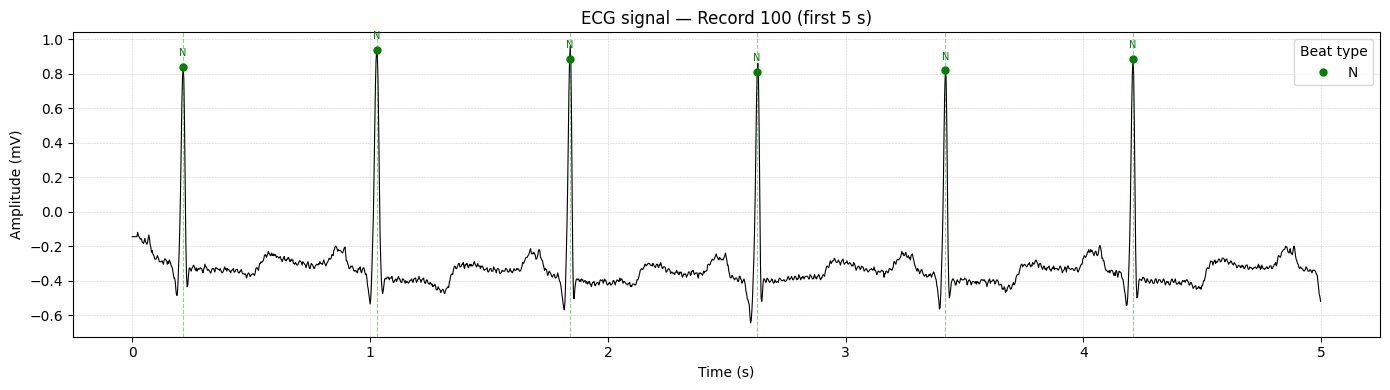

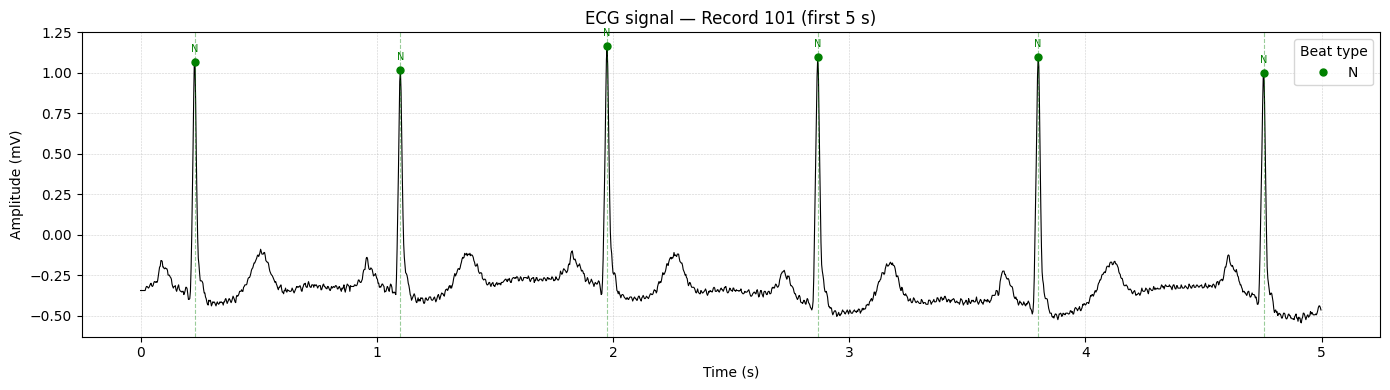

In [8]:
def plot_ecg_with_peaks(record_idx, title):
    n_samples = fs * 5
    signal = signal_ls[record_idx][:n_samples]
    peaks = peaks_pos_ls[record_idx]
    labels = labels_ls[record_idx]

    plt.figure(figsize=(14, 4))
    plt.plot(time_5sec, signal, color='k', linewidth=0.8)

    legend_added = set()
    for peak, label in zip(peaks, labels):
        if peak >= n_samples:
            break
        t = peak / fs
        color = class_colors[label]
        plt.axvline(x=t, color=color, linestyle='--', alpha=0.4, linewidth=0.8)
        plt.plot(t, signal[peak], 'o', color=color, markersize=5,
                 label=label if label not in legend_added else "")
        plt.text(t, signal[peak] + 0.05, label, fontsize=7,
                 color=color, ha='center', va='bottom')
        legend_added.add(label)

    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (mV)')
    plt.title(title)
    plt.legend(title='Beat type', loc='upper right')
    plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_ecg_with_peaks(0, f'ECG signal — Record {id_ls[0]} (first 5 s)')
plot_ecg_with_peaks(1, f'ECG signal — Record {id_ls[1]} (first 5 s)')

With a bar chart we can see how many beats are recorded for each class.

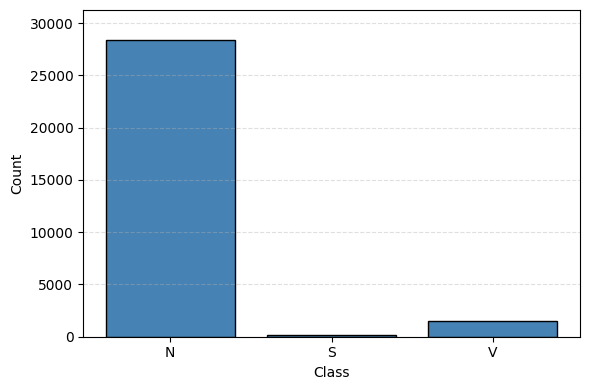

In [9]:
counts = Counter(list(chain.from_iterable(labels_ls)))
categories = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(6, 4))
plt.bar(categories, values, color='steelblue', edgecolor='black')

plt.xlabel('Class')
plt.ylabel('Count')
plt.ylim(0, max(values) * 1.1)  # leave some headroom
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [10]:
print(f"N: {round(values[0]/np.sum(values)*100,2)} %, S: {round(values[1]/np.sum(values)*100,2)} %, V: {round(values[2]/np.sum(values)*100,2)} %")

N: 94.2 %, S: 0.68 %, V: 5.12 %


- A clear skewness toward the normal beats (N) can be observed. Only a few beats are ventricular ectopic (V) and even less are supraventricular ectopic (S).
- This will probably affect the training process of the models, causing the predictions on Normal beats to be more accurate than predictions on V and S-type beats. 

In order to **extract the features** of each beat, in some cases we need to treat the first beats differently. Namely, this is what we are going to do for the features that use previous beats in their computation:
- **RR_current**: it is the time difference between the current and previous beat. For the first beat, since there are no previous beats, we set RR_current to 0, as if there was no difference at all.
- **RR_prev**: it is the time difference between the previous beat and the beat before that. For the first 2 beats, we set RR_prev to 0.
- **RR_local_mean** = it is the mean of the 4 previous intervals to the current beat. The time until the first beat is not considered in the mean computation, since it is often cut. Thus, the local mean is set to 0 for the first beat only. For the following beats until the 4th, we compute the mean with the available intervals in each iteration.

In [11]:
## Feature extraction
import numpy as np

rr_current_ls = []
rr_prev_ls = []
rr_ratio_ls = []
rr_local_mean_ls = []
r_amplitude_ls = []
qrs_duration_ls = []
qrs_energy_ls = []
st_mean_ls = []

for l, indiv_pos_ls in enumerate(peaks_pos_ls):
    rr_current = []
    rr_prev = []
    rr_ratio = []
    rr_local_mean = []
    r_amplitude = []
    qrs_duration = []
    qrs_energy = []
    st_mean = []
    
    # Precompute all RR intervals (ms) for this record
    rr_intervals_ms = []
    for i in range(len(indiv_pos_ls)):
        if i == 0:
            rr_intervals_ms.append(0)   
        else:
            interval = (indiv_pos_ls[i] - indiv_pos_ls[i-1]) / 360 * 1000
            rr_intervals_ms.append(interval)
    
    for i, pos in enumerate(indiv_pos_ls):
        # ----- RR_current -----
        if i == 0:
            rr_current.append(0)
        else:
            rr_current.append(rr_intervals_ms[i])
        
        # ----- RR_prev -----
        if i < 2:
            rr_prev.append(0)
        else:
            rr_prev.append(rr_intervals_ms[i-1])
        
        # ----- RR_local_mean : mean of 5-beat window (beats i-4 to i) -----
        start_idx = max(0, i-4)
        window = rr_intervals_ms[start_idx : i+1]   # includes current
        local_mean = np.mean(window)
        rr_local_mean.append(local_mean)
        
        # ----- RR_ratio = RR_current / RR_local_mean (avoid division by zero) -----
        if local_mean == 0:
            rr_ratio.append(1.0)
        else:
            rr_ratio.append(rr_current[-1] / local_mean)
        
        # ----- R_amplitude -----
        amp_window = signal_ls[l][max(0, pos-5) : min(len(signal_ls[l]), pos+6)]
        r_amplitude.append(max(amp_window))
        
        # ----- QRS_duration : half‑amplitude crossings -----
        half_amp_pre = pos
        half_amp_pos = pos
        # move left while signal >= half of R amplitude
        while half_amp_pre > 0 and signal_ls[l][half_amp_pre] >= 0.5 * signal_ls[l][pos]:
            half_amp_pre -= 1
        # move right while signal >= half of R amplitude
        while half_amp_pos < len(signal_ls[l])-1 and signal_ls[l][half_amp_pos] >= 0.5 * signal_ls[l][pos]:
            half_amp_pos += 1
        qrs_duration.append(half_amp_pos - half_amp_pre)
        
        # ----- QRS_energy : sum of squares ±20 samples -----
        start = max(0, pos-20)
        end = min(len(signal_ls[l]), pos+21)
        qrs_energy_val = np.sum(signal_ls[l][start:end] ** 2)
        qrs_energy.append(qrs_energy_val)
        
        # ----- ST_mean : mean of samples +40 to +120 -----
        st_start = pos + 40
        st_end = pos + 121
        if st_end > len(signal_ls[l]):
            st_mean_val = np.mean(signal_ls[l][st_start:])
        else:
            st_mean_val = np.mean(signal_ls[l][st_start:st_end])
        st_mean.append(st_mean_val)
    
    # Append lists for this record
    rr_current_ls.append(rr_current)
    rr_prev_ls.append(rr_prev)
    rr_ratio_ls.append(rr_ratio)
    rr_local_mean_ls.append(rr_local_mean)
    r_amplitude_ls.append(r_amplitude)
    qrs_duration_ls.append(qrs_duration)
    qrs_energy_ls.append(qrs_energy)
    st_mean_ls.append(st_mean)


C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [12]:
feature_df = pd.DataFrame()
feature_df["record_id"] = id_ls
feature_df["RR_current"] = rr_current_ls
feature_df["RR_prev"] = rr_prev_ls
feature_df["RR_ratio"] = rr_ratio_ls
feature_df["RR_local_mean"] = rr_local_mean_ls
feature_df["R_amplitude"] = r_amplitude_ls
feature_df["QRS_duration"] = qrs_duration_ls
feature_df["QRS_energy"] = qrs_energy_ls
feature_df["ST_mean"] = st_mean_ls
feature_df["target"] = labels_ls

In [13]:
feature_df = feature_df.explode(
    ["RR_current", "RR_prev", "RR_ratio", "RR_local_mean",
     "R_amplitude", "QRS_duration", "QRS_energy", "ST_mean", "target"],
    ignore_index=True
)

In [14]:
feature_df

,record_id,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean,target
0,100,0,0,1.0,0.0,0.84,6,6.79495,-0.342469,N
1,100,813.888889,0,2.0,406.944444,0.94,8,8.9521,-0.409691,N
2,100,811.111111,813.888889,1.497436,541.666667,0.96,6,9.1483,-0.39358,N
3,100,788.888889,811.111111,1.30725,603.472222,0.86,6,9.5219,-0.364815,N
4,100,791.666667,788.888889,1.234835,641.111111,0.82,6,8.0761,-0.403025,N
...,...,...,...,...,...,...,...,...,...,...
30157,219,813.888889,747.222222,0.946994,859.444444,1.765,13,29.406025,-0.486173,N
30158,219,405.555556,813.888889,0.522175,776.666667,1.59,13,33.5462,-0.761358,V
30159,219,938.888889,405.555556,1.306028,718.888889,1.275,11,33.936025,-1.441481,N
30160,219,761.111111,938.888889,1.037879,733.333333,1.45,11,29.501425,-0.948272,N


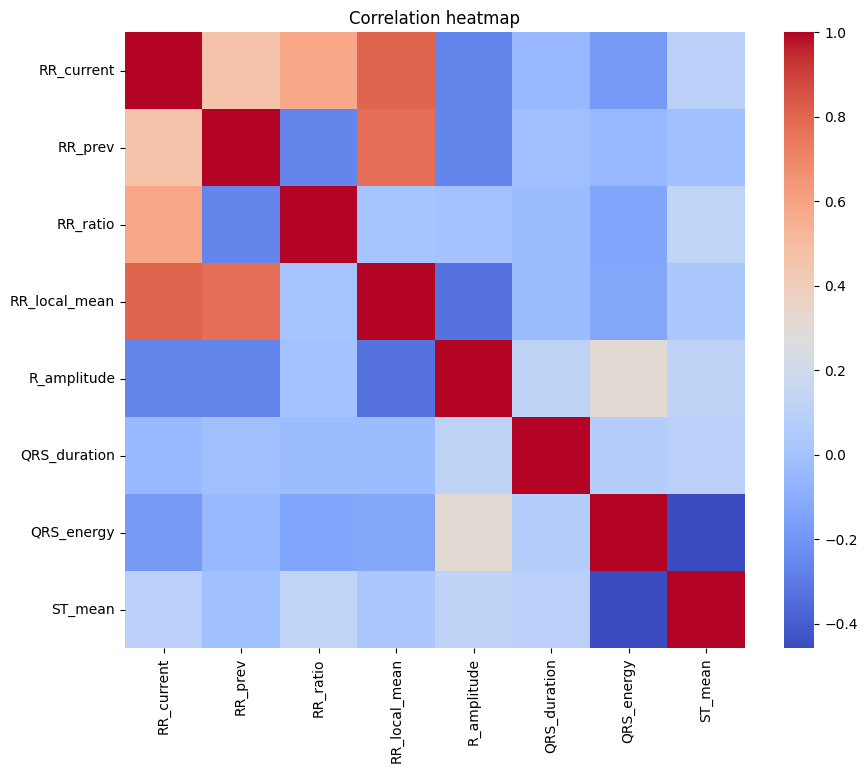

Top correlated pairs:
RR_current     RR_local_mean    0.805369
RR_prev        RR_local_mean    0.776005
RR_current     RR_ratio         0.588832
               RR_prev          0.461924
R_amplitude    QRS_energy       0.305115
RR_ratio       ST_mean          0.127494
R_amplitude    ST_mean          0.117866
               QRS_duration     0.116575
RR_current     ST_mean          0.098501
QRS_duration   ST_mean          0.095917
               QRS_energy       0.073854
RR_local_mean  ST_mean          0.035428
RR_ratio       RR_local_mean    0.011813
               R_amplitude     -0.000528
RR_prev        ST_mean         -0.013155
               QRS_duration    -0.016403
RR_local_mean  QRS_duration    -0.031722
RR_ratio       QRS_duration    -0.035183
RR_current     QRS_duration    -0.045053
RR_prev        QRS_energy      -0.048050
dtype: float64


In [15]:
plt.figure(figsize=(10, 8))
corr_matrix = feature_df.drop(['record_id', 'target'], axis=1).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()

# Find the most correlated pairs of features
pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))
print("Top correlated pairs:")
print(pairs.head(20))

- Both **RR_current** and **RR_prev** are highly correlated with **RR_local_mean**. This is due to intervals not varying much within 4 consecutive beats.
- **RR_current** and **RR_ratio** are highly correlated, since they are directly proportional.
- **RR_current** and **RR_prev** are also correlated feautres. It makes sense as beat intervals should not vary much from one beat to the next.
- **R_amplitude** has some (weak) correlation with **QRS_energy**, since the latter is a sum of R_amplitude with the surrounding amplitudes.

Standard scaling is performed on all 8 features and data split into 80 % train and 20% test sets. 

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [17]:
X = feature_df.drop(columns=['record_id', 'target'])
y = feature_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # We fit the scaler only on the training set to avoid data leakage
X_test_scaled = scaler.transform(X_test) # We transform the test data using the fitted scaler
# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean
8543,-1.459856,1.607312,-2.609003,0.041183,0.059887,-0.013792,0.184316,2.259643
21225,0.382889,2.342965,0.056771,0.437973,0.159377,-0.086091,0.826104,-1.116000
14779,0.240141,0.303786,0.188197,0.164774,-0.083130,0.058507,-0.751384,1.259058
8892,0.914949,1.284657,-0.319827,1.442955,-0.785778,0.311554,-0.973806,0.595607
20046,1.771436,1.633124,0.140365,2.080419,-2.048057,-0.339138,0.814345,-0.169191


The class proportions are preserved in train and test datasets:

In [19]:
# We check the distribution of classes in the training and test sets
print(f"Train: {len(X_train)} (Normal: {sum(y_train=="N")}, Supraventricular ectopic: {sum(y_train=="S")}, Ventricular ectopic: {sum(y_train=="V")})")
print(f"In percentages, Normal: {round(sum(y_train=="N")/len(X_train)*100, 2)} %; Supraventricular ectopic: {round(sum(y_train=="S")/len(X_train)*100, 2)} %; Ventricular ectopic: {round(sum(y_train=="V")/len(X_train)*100, 2)} %")
print(f"Test: {len(X_test)} (Normal: {sum(y_test=="N")}, Supraventricular ectopic: {sum(y_test=="S")}, Ventricular ectopic: {sum(y_test=="V")})")
print(f"In percentages, Normal: {round(sum(y_test=="N")/len(X_test)*100, 2)} %; Supraventricular ectopic: {round(sum(y_test=="S")/len(X_test)*100, 2)} %; Ventricular ectopic: {round(sum(y_test=="V")/len(X_test)*100, 2)} %")

SyntaxError: f-string: unmatched '(' (1618847952.py, line 2)

**Construction of sliding window dataset for RNN and LSTM models**

Create a dataset with consecutive vectors of 10 beats accross the 8 features (10 x 8)

In [20]:
Xw, yw = [], []
window = 10
X = feature_df.drop(columns=['record_id', 'target'])
y = feature_df['target']

for i in range(window - 1, len(X)):
    Xw.append(X[i - window + 1:i + 1])  # beats i-9 through i
    yw.append(y[i])                     # label of beat i

X_seq = np.array(Xw)
y_seq = np.array(yw)

In [21]:
X_seq

array([[[0, 0, 1.0, ..., np.int64(6), np.float64(6.79495),
         np.float64(-0.3424691358024692)],
        [np.float64(813.8888888888889), 0, np.float64(2.0), ...,
         np.int64(8), np.float64(8.952100000000002),
         np.float64(-0.40969135802469137)],
        [np.float64(811.1111111111111), np.float64(813.8888888888889),
         np.float64(1.4974358974358974), ..., np.int64(6),
         np.float64(9.148299999999999),
         np.float64(-0.39358024691358023)],
        ...,
        [np.float64(652.7777777777778), np.float64(816.6666666666666),
         np.float64(0.8502170767004343), ..., np.int64(6),
         np.float64(8.57275), np.float64(-0.38888888888888884)],
        [np.float64(994.4444444444445), np.float64(652.7777777777778),
         np.float64(1.2293956043956045), ..., np.int64(7),
         np.float64(9.512075), np.float64(-0.4432716049382716)],
        [np.float64(844.4444444444445), np.float64(994.4444444444445),
         np.float64(1.0305084745762711), ..., np

In [22]:
y_seq

array(['N', 'N', 'N', ..., 'N', 'N', 'N'], shape=(30153,), dtype='<U1')

Apply again 80/20 split:

In [23]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

#### Data Cleaning, we remove NaN values

After creating the sliding window dataset, we identify and remove any samples containing NaN values. These typically occur at the boundaries when feature extraction windows exceed the available signal length.

In [24]:
# We check for NaN and inf values in the sliding window dataset
print("Data Quality Check ")
Xw_train_array = np.stack([np.asarray(window, dtype=np.float32) for window in Xw_train])
Xw_test_array = np.stack([np.asarray(window, dtype=np.float32) for window in Xw_test])

print(f"Xw_train NaN count: {np.isnan(Xw_train_array).sum()}")
print(f"Xw_train inf count: {np.isinf(Xw_train_array).sum()}")
print(f"Xw_test NaN count: {np.isnan(Xw_test_array).sum()}")
print(f"Xw_test inf count: {np.isinf(Xw_test_array).sum()}")

# We remove samples with NaN values (they occur at signal boundaries in feature extraction)
mask_train = ~np.isnan(Xw_train_array).any(axis=(1,2))
mask_test = ~np.isnan(Xw_test_array).any(axis=(1,2))

X_train_w_clean = Xw_train_array[mask_train]
y_train_w_clean = yw_train[mask_train]
X_test_w_clean = Xw_test_array[mask_test]
y_test_w_clean = yw_test[mask_test]

print(f"\nAfter removing NaN samples:")
print(f"Xw_train: {Xw_train_array.shape} → {X_train_w_clean.shape}")
print(f"Xw_test: {Xw_test_array.shape} → {X_test_w_clean.shape}")
print(f"yw_train: {yw_train.shape} → {y_train_w_clean.shape}")
print(f"yw_test: {yw_test.shape} → {y_test_w_clean.shape}")

# We verify that no NaN remains
print(f"\nVerification - NaN count after cleaning:")
print(f"X_train_w_clean: {np.isnan(X_train_w_clean).sum()}")
print(f"X_test_w_clean: {np.isnan(X_test_w_clean).sum()}")

Data Quality Check 
Xw_train NaN count: 16
Xw_train inf count: 0
Xw_test NaN count: 4
Xw_test inf count: 0

After removing NaN samples:
Xw_train: (24122, 10, 8) → (24106, 10, 8)
Xw_test: (6031, 10, 8) → (6027, 10, 8)
yw_train: (24122,) → (24106,)
yw_test: (6031,) → (6027,)

Verification - NaN count after cleaning:
X_train_w_clean: 0
X_test_w_clean: 0


In [25]:
# We repair cleaned labels for Task 3
le = LabelEncoder()
y_train_w_enc_clean = le.fit_transform(y_train_w_clean)
y_test_w_enc_clean = le.transform(y_test_w_clean)

print(f"Label encoding complete. Classes: {le.classes_}")
print(f"Train label distribution: {np.unique(y_train_w_enc_clean, return_counts=True)}")
print(f"Test label distribution: {np.unique(y_test_w_enc_clean, return_counts=True)}")

Label encoding complete. Classes: ['N' 'S' 'V']
Train label distribution: (array([0, 1, 2]), array([22707,   164,  1235]))
Test label distribution: (array([0, 1, 2]), array([5677,   41,  309]))


## Task 3. RNN Sequence Classification

Libraries

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

We create a class to train the dataset in each Window created

In [27]:
class ECGWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_dataset_clean = ECGWindowDataset(X_train_w_clean, y_train_w_enc_clean)
test_dataset_clean  = ECGWindowDataset(X_test_w_clean, y_test_w_enc_clean)

train_loader_clean = DataLoader(train_dataset_clean, batch_size=batch_size, shuffle=True)
test_loader_clean  = DataLoader(test_dataset_clean,  batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with clean data")
print(f"Train batches: {len(train_loader_clean)}, Test batches: {len(test_loader_clean)}")

DataLoaders created with clean data
Train batches: 377, Test batches: 95


We create the class for the model VanillaRNN with all the specs and characteristics needed

In [28]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=1, num_classes=3):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)          
        out = out[:, -1, :]           
        out = self.dropout(out)
        return self.fc(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = VanillaRNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Using device: cpu


We train the dataset in the windows range and the model VanillaRNN in 30 epochs

In [29]:
epochs = 30
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader_clean:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        _, pred = torch.max(outputs, 1)
        correct += (pred == y_batch).sum().item()
        total += X_batch.size(0)

    train_loss = total_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader_clean:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            _, pred = torch.max(outputs, 1)
            correct += (pred == y_batch).sum().item()
            total += X_batch.size(0)

    val_loss = total_loss / total
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch  1/30 | Train Loss: 0.1758 | Train Acc: 0.9374 | Val Loss: 0.0981 | Val Acc: 0.9670
Epoch  2/30 | Train Loss: 0.1078 | Train Acc: 0.9674 | Val Loss: 0.0955 | Val Acc: 0.9720
Epoch  3/30 | Train Loss: 0.1085 | Train Acc: 0.9682 | Val Loss: 0.0919 | Val Acc: 0.9680
Epoch  4/30 | Train Loss: 0.1037 | Train Acc: 0.9692 | Val Loss: 0.0921 | Val Acc: 0.9740
Epoch  5/30 | Train Loss: 0.1082 | Train Acc: 0.9694 | Val Loss: 0.0859 | Val Acc: 0.9743
Epoch  6/30 | Train Loss: 0.1060 | Train Acc: 0.9710 | Val Loss: 0.0832 | Val Acc: 0.9740
Epoch  7/30 | Train Loss: 0.1060 | Train Acc: 0.9700 | Val Loss: 0.0831 | Val Acc: 0.9743
Epoch  8/30 | Train Loss: 0.1074 | Train Acc: 0.9713 | Val Loss: 0.0873 | Val Acc: 0.9730
Epoch  9/30 | Train Loss: 0.1012 | Train Acc: 0.9705 | Val Loss: 0.0814 | Val Acc: 0.9771
Epoch 10/30 | Train Loss: 0.1022 | Train Acc: 0.9696 | Val Loss: 0.0818 | Val Acc: 0.9768
Epoch 11/30 | Train Loss: 0.1012 | Train Acc: 0.9707 | Val Loss: 0.0913 | Val Acc: 0.9748
Epoch 12/3

Plotting Accuracy Curves

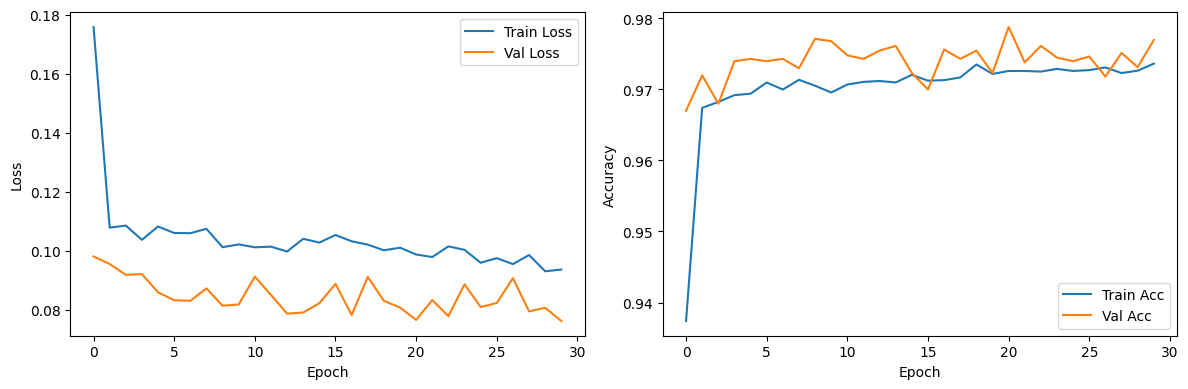

In [30]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Evaluation reports

In [31]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader_clean:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        _, pred = torch.max(outputs, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=le.classes_))


              precision    recall  f1-score   support

           N       0.98      0.99      0.99      5677
           S       0.75      0.22      0.34        41
           V       0.82      0.75      0.79       309

    accuracy                           0.98      6027
   macro avg       0.85      0.66      0.71      6027
weighted avg       0.98      0.98      0.97      6027



Confusion matrix

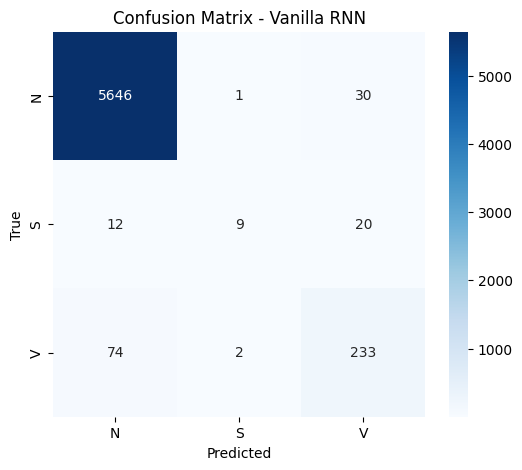

In [32]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Vanilla RNN')
plt.show()



F1 Score

In [33]:
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"Macro F1 Score: {macro_f1:.4f}")

Macro F1 Score: 0.7055


## Task 3.5. Extension: LSTM

We are going to create a LSTM classification model, so we create the class to specify the exact model

In [34]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=1, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out)



We train the LSTM with the same hyperparameters and window slicer that we did in the VanillaRNN

In [35]:
lstm_model = LSTMClassifier().to(device)
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)

We train the model with our dataset, in 30 epochs, the same exact way we did on the RNN

In [36]:
lstm_epochs = 30
lstm_train_losses, lstm_val_losses = [], []
lstm_train_accs, lstm_val_accs = [], []

for epoch in range(lstm_epochs):
    lstm_model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader_clean:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        lstm_optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = lstm_criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        lstm_optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        _, pred = torch.max(outputs, 1)
        correct += (pred == y_batch).sum().item()
        total += X_batch.size(0)

    lstm_train_loss = total_loss / total
    lstm_train_acc = correct / total
    lstm_train_losses.append(lstm_train_loss)
    lstm_train_accs.append(lstm_train_acc)

    lstm_model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader_clean:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = lstm_model(X_batch)
            loss = lstm_criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            _, pred = torch.max(outputs, 1)
            correct += (pred == y_batch).sum().item()
            total += X_batch.size(0)

    lstm_val_loss = total_loss / total
    lstm_val_acc = correct / total
    lstm_val_losses.append(lstm_val_loss)
    lstm_val_accs.append(lstm_val_acc)

    print(f"LSTM Epoch {epoch+1:2d}/{lstm_epochs} | Train Loss: {lstm_train_loss:.4f} | Train Acc: {lstm_train_acc:.4f} | Val Loss: {lstm_val_loss:.4f} | Val Acc: {lstm_val_acc:.4f}")



LSTM Epoch  1/30 | Train Loss: 0.2340 | Train Acc: 0.9347 | Val Loss: 0.0944 | Val Acc: 0.9726
LSTM Epoch  2/30 | Train Loss: 0.1038 | Train Acc: 0.9696 | Val Loss: 0.0879 | Val Acc: 0.9743
LSTM Epoch  3/30 | Train Loss: 0.0995 | Train Acc: 0.9698 | Val Loss: 0.0933 | Val Acc: 0.9746
LSTM Epoch  4/30 | Train Loss: 0.0956 | Train Acc: 0.9716 | Val Loss: 0.0775 | Val Acc: 0.9766
LSTM Epoch  5/30 | Train Loss: 0.0975 | Train Acc: 0.9716 | Val Loss: 0.0875 | Val Acc: 0.9733
LSTM Epoch  6/30 | Train Loss: 0.0961 | Train Acc: 0.9702 | Val Loss: 0.0745 | Val Acc: 0.9758
LSTM Epoch  7/30 | Train Loss: 0.0936 | Train Acc: 0.9721 | Val Loss: 0.0785 | Val Acc: 0.9751
LSTM Epoch  8/30 | Train Loss: 0.0914 | Train Acc: 0.9720 | Val Loss: 0.0801 | Val Acc: 0.9766
LSTM Epoch  9/30 | Train Loss: 0.0902 | Train Acc: 0.9725 | Val Loss: 0.0718 | Val Acc: 0.9751
LSTM Epoch 10/30 | Train Loss: 0.0916 | Train Acc: 0.9710 | Val Loss: 0.0763 | Val Acc: 0.9751
LSTM Epoch 11/30 | Train Loss: 0.0892 | Train Acc:

We plot some training and accuracy curves as we did in vanilla RNN

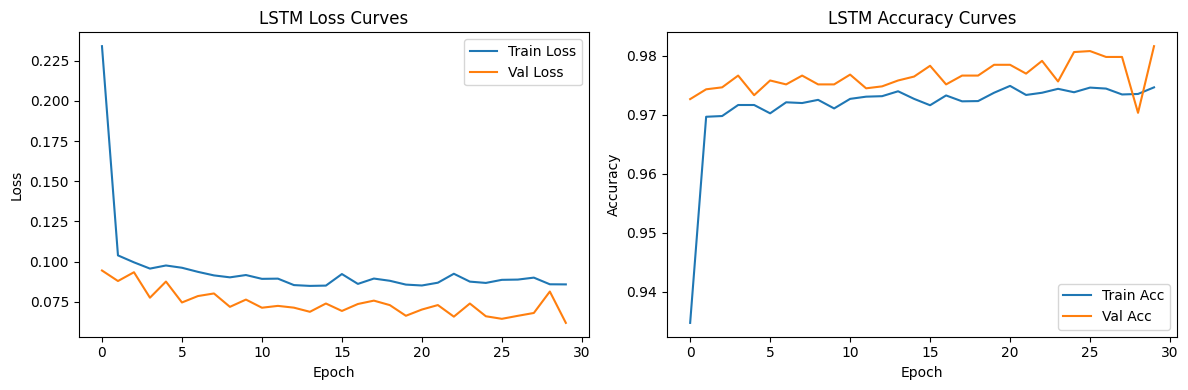

In [37]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(lstm_train_losses, label='Train Loss')
plt.plot(lstm_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss Curves')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(lstm_train_accs, label='Train Acc')
plt.plot(lstm_val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Accuracy Curves')
plt.legend()
plt.tight_layout()
plt.show()



We evaluate the model LSTM with the test dataset and create an evaluation report

In [38]:
lstm_model.eval()
lstm_all_preds = []
lstm_all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader_clean:
        X_batch = X_batch.to(device)
        outputs = lstm_model(X_batch)
        _, pred = torch.max(outputs, 1)
        lstm_all_preds.extend(pred.cpu().numpy())
        lstm_all_labels.extend(y_batch.numpy())

lstm_report_dict = classification_report(lstm_all_labels, lstm_all_preds, target_names=le.classes_, output_dict=True, zero_division=0)
print(classification_report(lstm_all_labels, lstm_all_preds, target_names=le.classes_, zero_division=0))



              precision    recall  f1-score   support

           N       0.99      1.00      0.99      5677
           S       0.89      0.20      0.32        41
           V       0.88      0.80      0.84       309

    accuracy                           0.98      6027
   macro avg       0.92      0.66      0.72      6027
weighted avg       0.98      0.98      0.98      6027



We create a confussion Matrix

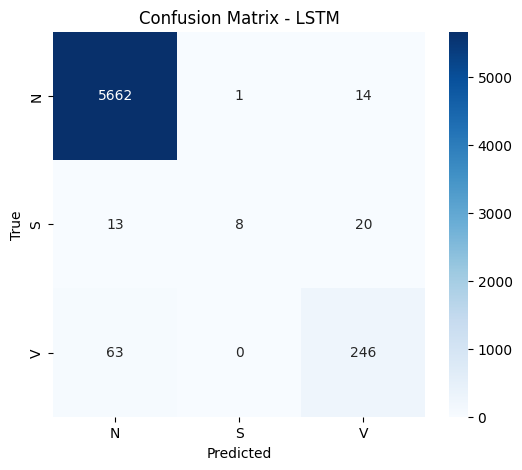

In [39]:
cm = confusion_matrix(lstm_all_labels, lstm_all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - LSTM')
plt.show()

We create and F1 socre report

In [40]:
lstm_macro_f1 = f1_score(lstm_all_labels, lstm_all_preds, average='macro')
print(f"LSTM Macro F1 Score: {lstm_macro_f1:.4f}")


LSTM Macro F1 Score: 0.7158


Comparison between Vanilla RNN and the LSTM model

In [41]:
rnn_report_dict = classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True, zero_division=0)
rnn_macro_f1 = macro_f1
print("\n RNN vs LSTM Comparison ")
print(f"Macro F1 - RNN:  {rnn_macro_f1:.4f} LSTM: {lstm_macro_f1:.4f}")
print(f"Recall S - RNN:   {rnn_report_dict['S']['recall']:.4f}  LSTM:  {lstm_report_dict['S']['recall']:.4f}")
print(f"Recall V - RNN:   {rnn_report_dict['V']['recall']:.4f}  LSTM:  {lstm_report_dict['V']['recall']:.4f}")


 RNN vs LSTM Comparison 
Macro F1 - RNN:  0.7055 LSTM: 0.7158
Recall S - RNN:   0.2195  LSTM:  0.1951
Recall V - RNN:   0.7540  LSTM:  0.7961


##### Second attempt: balanced training to improve S-class recall

The S class is still poorly detected, so we change the training strategy instead of only changing the architecture. Here we keep the same LSTM model and hyperparameters, but we build a balanced sampler for the training loader so minority classes appear more often during optimization. This is meant to improve minority-class recall, especially for S, even if that does not necessarily maximize the global macro F1 score.

Library

In [42]:
from torch.utils.data import WeightedRandomSampler

Training LSTM in a balanced weight to see if changes are made in class S 

In [43]:
train_class_counts = np.bincount(y_train_w_enc_clean, minlength=3)
train_sample_weights = 1.0 / train_class_counts[y_train_w_enc_clean]
balanced_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(train_sample_weights, dtype=torch.double),
    num_samples=len(train_sample_weights),
    replacement=True
)
balanced_train_loader = DataLoader(
    train_dataset_clean,
    batch_size=batch_size,
    sampler=balanced_sampler
)

balanced_lstm = LSTMClassifier().to(device)
balanced_criterion = nn.CrossEntropyLoss()
balanced_optimizer = optim.Adam(balanced_lstm.parameters(), lr=0.001, weight_decay=1e-5)

balanced_train_losses, balanced_val_losses = [], []
balanced_train_accs, balanced_val_accs = [], []

Executing the model with the new balanced weights

In [44]:
for epoch in range(lstm_epochs):
    balanced_lstm.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in balanced_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        balanced_optimizer.zero_grad()
        outputs = balanced_lstm(X_batch)
        loss = balanced_criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(balanced_lstm.parameters(), max_norm=1.0)
        balanced_optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        _, pred = torch.max(outputs, 1)
        correct += (pred == y_batch).sum().item()
        total += X_batch.size(0)

    balanced_train_loss = total_loss / total
    balanced_train_acc = correct / total
    balanced_train_losses.append(balanced_train_loss)
    balanced_train_accs.append(balanced_train_acc)

    balanced_lstm.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader_clean:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = balanced_lstm(X_batch)
            loss = balanced_criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            _, pred = torch.max(outputs, 1)
            correct += (pred == y_batch).sum().item()
            total += X_batch.size(0)

    balanced_val_loss = total_loss / total
    balanced_val_acc = correct / total
    balanced_val_losses.append(balanced_val_loss)
    balanced_val_accs.append(balanced_val_acc)
    print(f"Balanced LSTM Epoch {epoch+1:2d}/{lstm_epochs} | Train Loss: {balanced_train_loss:.4f} | Train Acc: {balanced_train_acc:.4f} | Val Loss: {balanced_val_loss:.4f} | Val Acc: {balanced_val_acc:.4f}")




Balanced LSTM Epoch  1/30 | Train Loss: 0.6803 | Train Acc: 0.7581 | Val Loss: 0.3023 | Val Acc: 0.9298
Balanced LSTM Epoch  2/30 | Train Loss: 0.4435 | Train Acc: 0.8455 | Val Loss: 0.2291 | Val Acc: 0.9374
Balanced LSTM Epoch  3/30 | Train Loss: 0.3732 | Train Acc: 0.8680 | Val Loss: 0.2205 | Val Acc: 0.9321
Balanced LSTM Epoch  4/30 | Train Loss: 0.3461 | Train Acc: 0.8773 | Val Loss: 0.2699 | Val Acc: 0.9086
Balanced LSTM Epoch  5/30 | Train Loss: 0.3421 | Train Acc: 0.8777 | Val Loss: 0.2523 | Val Acc: 0.9217
Balanced LSTM Epoch  6/30 | Train Loss: 0.3248 | Train Acc: 0.8814 | Val Loss: 0.2832 | Val Acc: 0.9104
Balanced LSTM Epoch  7/30 | Train Loss: 0.3447 | Train Acc: 0.8692 | Val Loss: 0.2184 | Val Acc: 0.9311
Balanced LSTM Epoch  8/30 | Train Loss: 0.3472 | Train Acc: 0.8719 | Val Loss: 0.2010 | Val Acc: 0.9333
Balanced LSTM Epoch  9/30 | Train Loss: 0.3465 | Train Acc: 0.8699 | Val Loss: 0.2043 | Val Acc: 0.9404
Balanced LSTM Epoch 10/30 | Train Loss: 0.3392 | Train Acc: 0.86

We evaluate this new LSTM model

In [45]:
balanced_lstm.eval()
balanced_preds = []
balanced_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader_clean:
        X_batch = X_batch.to(device)
        outputs = balanced_lstm(X_batch)
        _, pred = torch.max(outputs, 1)
        balanced_preds.extend(pred.cpu().numpy())
        balanced_labels.extend(y_batch.numpy())

We compare the Balanced LSTM with the Vanilla LSTM

In [46]:

balanced_report_dict = classification_report(balanced_labels, balanced_preds, target_names=le.classes_, output_dict=True, zero_division=0)
balanced_macro_f1 = f1_score(balanced_labels, balanced_preds, average='macro')
print("\nBalanced LSTM classification report:")
print(classification_report(balanced_labels, balanced_preds, target_names=le.classes_, zero_division=0))
print(f"Balanced LSTM Macro F1 Score: {balanced_macro_f1:.4f}")
print("\n Balanced LSTM vs Vanilla LSTM ")
print(f"Macro F1 - Vanilla LSTM:   {lstm_macro_f1:.4f}")
print(f"Macro F1 - Balanced LSTM: {balanced_macro_f1:.4f}")
print(f"Recall S - Vanilla LSTM:   {lstm_report_dict['S']['recall']:.4f}")
print(f"Recall S - Balanced LSTM:  {balanced_report_dict['S']['recall']:.4f}")
print(f"Recall V - Vanilla LSTM:   {lstm_report_dict['V']['recall']:.4f}")
print(f"Recall V - Balanced LSTM:  {balanced_report_dict['V']['recall']:.4f}")


Balanced LSTM classification report:
              precision    recall  f1-score   support

           N       1.00      0.91      0.95      5677
           S       0.12      0.93      0.21        41
           V       0.54      0.89      0.67       309

    accuracy                           0.91      6027
   macro avg       0.55      0.91      0.61      6027
weighted avg       0.97      0.91      0.93      6027

Balanced LSTM Macro F1 Score: 0.6102

 Balanced LSTM vs Vanilla LSTM 
Macro F1 - Vanilla LSTM:   0.7158
Macro F1 - Balanced LSTM: 0.6102
Recall S - Vanilla LSTM:   0.1951
Recall S - Balanced LSTM:  0.9268
Recall V - Vanilla LSTM:   0.7961
Recall V - Balanced LSTM:  0.8900


## Task 4. Model Comparison & Evaluation

In [49]:
from sklearn.metrics import accuracy_score

summary_df = pd.DataFrame({
    'Model':['VanillaRNN', 'Vanilla LSTM', 'Balanced LSTM'],
    'Accuracy': [accuracy_score(all_labels,all_preds), accuracy_score(lstm_all_labels,lstm_all_preds), accuracy_score(balanced_labels, balanced_preds)],
    'F1 Macro':[f1_score(all_labels,all_preds, average='macro'), f1_score(lstm_all_labels,lstm_all_preds, average='macro'), f1_score(balanced_labels, balanced_preds, average='macro')],
    'F1 Weighted':[f1_score(all_labels,all_preds, average='weighted'), f1_score(lstm_all_labels,lstm_all_preds, average='weighted'), f1_score(balanced_labels, balanced_preds, average='weighted')]
})

summary_df

,Model,Accuracy,F1 Macro,F1 Weighted
0,VanillaRNN,0.976937,0.705510,0.974936
1,Vanilla LSTM,0.981583,0.715781,0.979422
2,Balanced LSTM,0.911565,0.610220,0.934148


### Final Model Comparison and Discussion

We compared three training setups on the same 10×8 sliding-window dataset:

- **Vanilla RNN**: baseline recurrent model with the original training pipeline.
- **Vanilla LSTM**: same hidden size, learning rate, epochs, dropout, and optimizer as the RNN, but using `nn.LSTM`.
- **Balanced LSTM**: same LSTM architecture, but trained with a weighted sampler so minority classes appear more often during optimization.

#### Results summary

- **Vanilla RNN**: By looking at the data on the *summary_df* table above, we can see that the Accuracy score is considerably high. This score tells us that the model is very good at classifying, in general, as it makes very few mistakes. Nonetheless, as we have mentioned before, the dataset we are working with is highly imbalanced; this detail makes the Accuracy score not that reliable, since we should be skeptical of it when we know the classes are imbalanced. Moreover, the big difference between the F1 Macro and Weighted scores supports this assumption, as the higher F1 Weighted score suggests the model is good at classyfing the class with more cases, but the lower F1 Macro suggests that not all classes are being classified correctly. With all of this, we conclude the model performs well on the normal class, but it still struggles with the minority classes, especially **S**.

- **Vanilla LSTM**: Also referencing the data on the *summary_df* table above, we can see a similar situation. However, not only does this model achieve the best macro F1 in the current results; by looking at both the **S** and **V** recall, we can confirm that the classification of these less common classes has been improved over the Vanilla RNN.

- **Balanced LSTM**: Looking at all three scores on the *summary_df* table above, this last model is not the best by macro F1 in this run. Despite performing the worst of all three models, Balanced LSTM is the strongest model for minority-class detection, with the highest **S**  and **V** recall. All thing considered, we could conclude that this last model is the worst classifer, and the reason is not precisely the imbalanced class, but the lack of diferentiation between the three classes. 

#### Why this happens

The main limitation is the class imbalance in the dataset, not the model architecture itself. The **S** class is extremely rare, so the vanilla models see too few examples of it during training. The balanced sampler changes the training distribution and forces the model to pay much more attention to minority classes, which is why the **S** recall rises sharply.

#### Takeaway

If the goal is overall macro F1, the **Vanilla LSTM** is the best model in the current evaluation. If the goal is clinically more useful minority-class detection, the **Balanced LSTM** is the better choice because it achieves much higher **S** recall. So the balanced approach makes sense as a targeted fix for class imbalance, but not as the top model by macro F1 in this run.